# Notebook B — May 2026 Predictions + Next Order Dates + Output
**Requires:** Notebook A to have been run first.

What this does:
1. Loads the saved XGBoost model (trained on Jan–Apr)
2. Scores all retailers for any May 2026 date → call priority list
3. Generates full May month call schedule
4. Predicts next order dates for all retailers (Phase 2 regression)

Outputs saved:
- `outputs/call_priority_YYYY-MM-DD.csv`
- `outputs/may_2026_call_schedule.csv`
- `outputs/next_order_prediction_may2026.csv`
- `models/xgboost_next_order_model.pkl`

---
## ⚙️ B0 — Configuration (UPDATE YOUR PATH HERE)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
from datetime import timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

# ── UPDATE THIS ONE LINE ──────────────────────────────────────────────────────
BASE = r'C:\Users\Rishit\Desktop\O2R-Order-prediction'
# ─────────────────────────────────────────────────────────────────────────────

RAW_PATH       = os.path.join(BASE, 'data',      "Jan - May '26 Data.csv")
MODEL_PATH     = os.path.join(BASE, 'models',    'xgboost_order_model.pkl')
REG_MODEL_PATH = os.path.join(BASE, 'models',    'xgboost_next_order_model.pkl')
ENCODER_PATH   = os.path.join(BASE, 'processed', 'label_encoders.pkl')
PROFILE_PATH   = os.path.join(BASE, 'processed', 'retailer_profiles.parquet')
OUTPUTS_DIR    = os.path.join(BASE, 'outputs')

os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── SET YOUR TARGET DATE (any May 2026 date) ──────────────────────────────────
TARGET_DATE = '2026-05-15'   # ← change this to any date in May
TOP_K = 100            # ← dynamic top-k ranking
# ─────────────────────────────────────────────────────────────────────────────

print('✅ Setup complete.')
print(f'   Base folder  : {BASE}')
print(f'   Target date  : {TARGET_DATE}')
print(f'   Top-K        : {TOP_K}  (top-k retailers will be flagged to call)')


✅ Setup complete.
   Base folder  : C:\Users\Rishit\Desktop\O2R-Order-prediction
   Target date  : 2026-05-15
   Top-K        : 100  (top-k retailers will be flagged to call)


---
## 📥 B1 — Load Model, Encoders & Historical Orders

In [2]:
# Load classification model
with open(MODEL_PATH, 'rb') as f:
    saved = pickle.load(f)
model        = saved['model']
FEATURE_COLS = saved['feature_cols']

# Check if CatBoost model exists (if it outperformed XGBoost)
CAT_MODEL_PATH = os.path.join(BASE, 'models', 'catboost_order_model.pkl')
if os.path.exists(CAT_MODEL_PATH):
    print('\n🏆 CatBoost model found! Overriding XGBoost model.')
    with open(CAT_MODEL_PATH, 'rb') as f_cat:
        model = pickle.load(f_cat)

# Load encoders
with open(ENCODER_PATH, 'rb') as f:
    label_encoders = pickle.load(f)

# Load retailer profiles
retailer_profile = pd.read_parquet(PROFILE_PATH)

print(f'Model loaded   : trained on {saved["trained_on"]}')
print(f'Features       : {len(FEATURE_COLS)}')
print(f'Retailers      : {len(retailer_profile):,}')

# Load raw order history (Jan–May)
print('\nLoading historical orders...')
df = pd.read_csv(RAW_PATH)
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)
confirmed = df[df['orderStatus'].isin(['Delivered','PartiallyDelivered'])]
orders = confirmed.drop_duplicates(subset='orderNumber')[[
    'orderNumber','customerId','createdAt',
    'hubName','shopType','retailerType','orderSource'
]].copy().sort_values(['customerId','createdAt'])

HISTORY_END = orders['createdAt'].max()
print(f'Orders loaded  : {len(orders):,}')
print(f'History end    : {HISTORY_END.date()}')

Model loaded   : trained on Jan–Apr 2026
Features       : 27
Retailers      : 8,640

Loading historical orders...


Orders loaded  : 177,340
History end    : 2026-05-31


---
## 🔧 B2 — Feature Builder Function
Builds one feature row per retailer for any given date using only past history.

In [3]:
def build_features_for_date(orders, profile, encoders, target_date):
    """
    For a given target_date, compute features for every retailer
    using ONLY order history strictly before that date.
    Returns one feature row per retailer ready for model.predict_proba().
    """
    target_date = pd.Timestamp(target_date)
    hist        = orders[orders['createdAt'] < target_date].copy()

    # 1. Last order date & days since
    last_ord = hist.groupby('customerId')['createdAt'].max().reset_index()
    last_ord.columns = ['customerId','last_order_date']
    last_ord['days_since_last_order'] = (target_date - last_ord['last_order_date']).dt.days

    # 2. Rolling order counts
    def cnt(n):
        cut = target_date - pd.Timedelta(days=n)
        return (
            hist[hist['createdAt'] >= cut]
            .groupby('customerId')['orderNumber'].count()
            .reset_index()
            .rename(columns={'orderNumber': f'orders_last_{n}_days'})
        )

    # 3. Total orders so far
    total_sf = (
        hist.groupby('customerId')['orderNumber'].count()
        .reset_index().rename(columns={'orderNumber':'total_orders_so_far'})
    )

    # 4. Gap statistics
    hist_s = hist.sort_values(['customerId','createdAt'])
    hist_s['gap'] = hist_s.groupby('customerId')['createdAt'].diff().dt.days
    gap_stats = hist_s.groupby('customerId')['gap'].agg(
        avg_gap_between_orders='mean',
        std_gap_between_orders='std',
        median_gap='median'
    ).reset_index().fillna({'avg_gap_between_orders':30,
                             'std_gap_between_orders':0,
                             'median_gap':30})

    # 5. App ratio
    app_r = (
        hist.groupby('customerId')
        .apply(lambda x: (x['orderSource']=='App').mean())
        .reset_index()
    )
    app_r.columns = ['customerId','app_order_ratio']

    # Assemble
    f = (
        profile[['customerId','hubName','shopType','retailerType','first_order']]
        .merge(last_ord[['customerId','last_order_date','days_since_last_order']], on='customerId', how='left')
        .merge(cnt(3),    on='customerId', how='left')
        .merge(cnt(7),    on='customerId', how='left')
        .merge(cnt(14),   on='customerId', how='left')
        .merge(cnt(30),   on='customerId', how='left')
        .merge(total_sf,  on='customerId', how='left')
        .merge(gap_stats, on='customerId', how='left')
        .merge(app_r,     on='customerId', how='left')
    )

    # Fill nulls (retailers with no recent history)
    fill = {
        'days_since_last_order':999, 'orders_last_3_days':0,
        'orders_last_7_days':0, 'orders_last_14_days':0, 'orders_last_30_days':0,
        'total_orders_so_far':0, 'avg_gap_between_orders':30,
        'std_gap_between_orders':0, 'median_gap':30,
        'app_order_ratio':0.5, 'tenure_days':0
    }
    f = f.fillna(fill)
    f['tenure_days'] = (target_date - pd.to_datetime(f['first_order'])).dt.days
    f['tenure_days'] = f['tenure_days'].clip(lower=0).fillna(0)
    f['momentum_7_30'] = f['orders_last_7_days'] / (f['orders_last_30_days'] + 1)
    f['momentum_14_30'] = f['orders_last_14_days'] / (f['orders_last_30_days'] + 1)

    # Derived features
    f['days_overdue']     = (f['days_since_last_order'] - f['avg_gap_between_orders']).clip(lower=0)
    f['is_overdue']       = (f['days_overdue'] > 0).astype(int)
    f['order_regularity'] = 1 / (f['std_gap_between_orders'] + 1)
    f['overdue_ratio']    = (f['days_since_last_order'] / (f['avg_gap_between_orders']+1)).clip(upper=10).round(3)

    # Temporal
    f['day_of_week']    = target_date.dayofweek
    f['day_of_month']   = target_date.day
    f['week_of_month']  = (target_date.day - 1) // 7 + 1
    f['month']          = target_date.month
    f['is_weekend']     = int(target_date.dayofweek >= 5)
    f['is_month_start'] = int(target_date.day <= 3)
    f['is_month_end']   = int(target_date.day >= 28)
    f['date']           = target_date

    # Encode categoricals
    for col in ['hubName','shopType','retailerType']:
        le    = encoders[col]
        known = set(le.classes_)
        f[col]        = f[col].apply(lambda x: x if str(x) in known else le.classes_[0])
        f[col+'_enc'] = le.transform(f[col].astype(str))

    return f

print('✅ Feature builder function ready.')

✅ Feature builder function ready.


---
## 📋 B3 — Generate Call Priority List For TARGET_DATE

In [4]:
print(f'Building features for {TARGET_DATE}...')
features = build_features_for_date(orders, retailer_profile, label_encoders, TARGET_DATE)

X_score = np.nan_to_num(features[FEATURE_COLS].values, nan=0.0)
features = features.copy()
features['order_probability'] = model.predict_proba(X_score)[:, 1]
features = features.sort_values('order_probability', ascending=False)
features['will_order'] = 0
features.iloc[:TOP_K, features.columns.get_loc('will_order')] = 1

total     = len(features)
to_call   = int(features['will_order'].sum())
to_skip   = total - to_call
reduction = (1 - to_call/total) * 100

print(f'\n=== PREDICTION SUMMARY FOR {TARGET_DATE} ===')
print(f'Total retailers  : {total:,}')
print(f'📞 CALL today    : {to_call:,}   (Top {TOP_K})')
print(f'⏭️  SKIP today    : {to_skip:,}')
print(f'Call reduction   : {reduction:.1f}%')

COST_PER_MIN  = 8
AVG_CALL_MINS = 2
old_cost = total   * COST_PER_MIN * AVG_CALL_MINS
new_cost = to_call * COST_PER_MIN * AVG_CALL_MINS
print(f'\n💰 Cost before model : ₹{old_cost:,}/day')
print(f'💰 Cost with model   : ₹{new_cost:,}/day')
print(f'💸 Daily saving      : ₹{old_cost-new_cost:,}')

Building features for 2026-05-15...



=== PREDICTION SUMMARY FOR 2026-05-15 ===
Total retailers  : 8,640
📞 CALL today    : 100   (Top 100)
⏭️  SKIP today    : 8,540
Call reduction   : 98.8%

💰 Cost before model : ₹138,240/day
💰 Cost with model   : ₹1,600/day
💸 Daily saving      : ₹136,640


In [5]:
# Build output table
output = features[[
    'customerId','hubName','shopType','retailerType',
    'order_probability','will_order',
    'last_order_date','days_since_last_order',
    'avg_gap_between_orders','days_overdue',
    'orders_last_7_days','total_orders_so_far','app_order_ratio'
]].copy()

output['order_probability_pct']  = (output['order_probability'] * 100).round(1)
output['avg_gap_between_orders'] = output['avg_gap_between_orders'].round(1)
output['days_overdue']           = output['days_overdue'].round(1)
output['app_order_ratio']        = (output['app_order_ratio'] * 100).round(0).astype(int)

if 'last_order_date' in output.columns:
    output['last_order_date'] = pd.to_datetime(output['last_order_date']).dt.date

output['Action'] = output['will_order'].map({1:'📞 CALL', 0:'⏭️ SKIP'})
output = output.sort_values('order_probability', ascending=False).reset_index(drop=True)
output.index += 1
output.index.name = 'Rank'

print(f'=== TOP 20 RETAILERS TO CALL ON {TARGET_DATE} ===')
print(output[['customerId','hubName','shopType','order_probability_pct',
              'days_since_last_order','avg_gap_between_orders',
              'days_overdue','Action']].head(20).to_string())

# Save
out_path = os.path.join(OUTPUTS_DIR, f'call_priority_{TARGET_DATE}.csv')
output.reset_index().to_csv(out_path, index=False)
print(f'\n✅ Priority list saved → {out_path}')

=== TOP 20 RETAILERS TO CALL ON 2026-05-15 ===
      customerId                     hubName   shopType  order_probability_pct  days_since_last_order  avg_gap_between_orders  days_overdue  Action
Rank                                                                                                                                               
1      USR-45332  Cross Line Events (EDelhi)  General A              97.599998                    1.0                     1.3           0.0  📞 CALL
2      USR-45021  Cross Line Events (EDelhi)     Paan B              97.599998                    1.0                     1.4           0.0  📞 CALL
3      USR-25776        Instant Foods(Noida)     Paan B              97.400002                    1.0                     1.3           0.0  📞 CALL
4      USR-43064  Cross Line Events (EDelhi)  General A              97.400002                    2.0                     1.3           0.7  📞 CALL
5      USR-18654        Instant Foods(Noida)     Paan B          

---
## 📅 B4 — Full May 2026 Call Schedule (All 31 Days)
Runs the model for every day in May. Takes ~5 min.

Generating predictions for all May 2026 dates...


  2026-05-01 (Fri) → Call 100 retailers


  2026-05-02 (Sat) → Call 100 retailers


  2026-05-03 (Sun) → Call 100 retailers


  2026-05-04 (Mon) → Call 100 retailers


...

  2026-05-27 (Wed) → Call 100 retailers


  2026-05-28 (Thu) → Call 100 retailers


  2026-05-29 (Fri) → Call 100 retailers


  2026-05-30 (Sat) → Call 100 retailers


  2026-05-31 (Sun) → Call 100 retailers

✅ Full May schedule saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\outputs\may_2026_call_schedule.csv

=== MAY 2026 SUMMARY ===
Avg daily calls needed  : 100
Avg call reduction      : 98.8%
Total calls saved (May) : 264,740
Estimated May savings   : ₹4,235,840


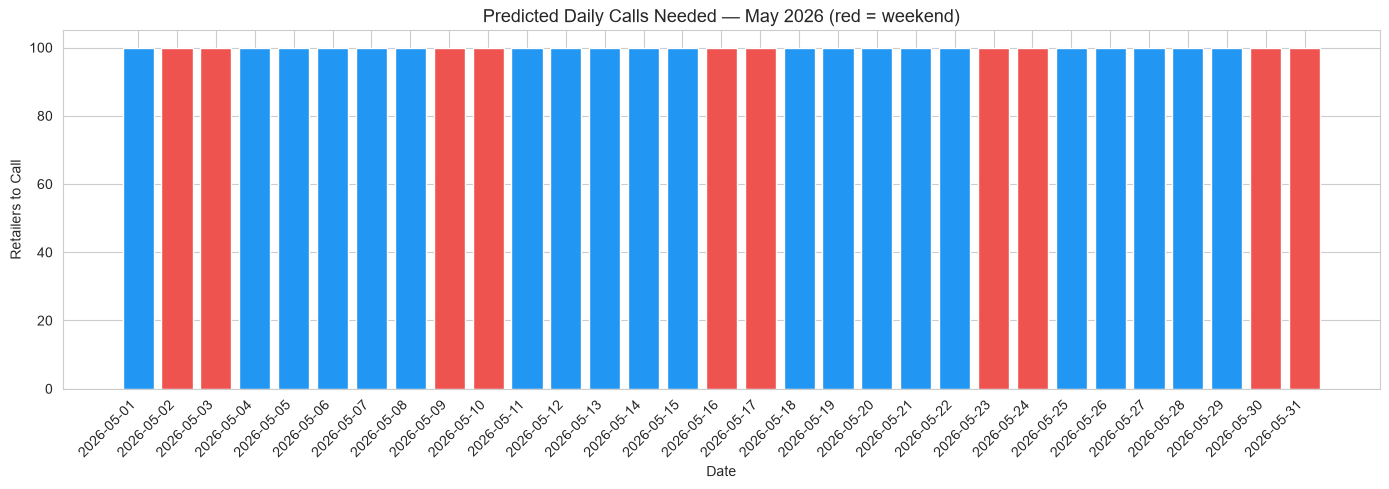

In [6]:
print('Generating predictions for all May 2026 dates...')
may_dates   = pd.date_range('2026-05-01', '2026-05-31', freq='D')
may_summary = []

for date in may_dates:
    f     = build_features_for_date(orders, retailer_profile, label_encoders, date)
    X     = np.nan_to_num(f[FEATURE_COLS].values, nan=0.0)
    probs = model.predict_proba(X)[:, 1]
    calls = min(TOP_K, len(probs))
    may_summary.append({
        'date'          : date.date(),
        'day'           : date.strftime('%A'),
        'calls_needed'  : calls,
        'skipped'       : len(f) - calls,
        'call_reduction': round((1 - calls/len(f))*100, 1)
    })
    print(f'  {date.date()} ({date.strftime("%a")}) → Call {calls:,} retailers')

may_df    = pd.DataFrame(may_summary)
sched_path = os.path.join(OUTPUTS_DIR, 'may_2026_call_schedule.csv')
may_df.to_csv(sched_path, index=False)

print(f'\n✅ Full May schedule saved → {sched_path}')
print(f'\n=== MAY 2026 SUMMARY ===')
print(f'Avg daily calls needed  : {may_df["calls_needed"].mean():.0f}')
print(f'Avg call reduction      : {may_df["call_reduction"].mean():.1f}%')

total_saved = may_df['skipped'].sum()
cost_saved  = total_saved * COST_PER_MIN * AVG_CALL_MINS
print(f'Total calls saved (May) : {total_saved:,}')
print(f'Estimated May savings   : ₹{cost_saved:,}')

# Plot
plt.figure(figsize=(14,5))
bar_colors = ['#ef5350' if d == 'Saturday' or d == 'Sunday' else '#2196F3'
              for d in may_df['day']]
plt.bar(may_df['date'].astype(str), may_df['calls_needed'], color=bar_colors)
plt.title('Predicted Daily Calls Needed — May 2026 (red = weekend)', fontsize=13)
plt.xlabel('Date'); plt.ylabel('Retailers to Call')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

---
## 🗓️ B5 — Next Order Date Prediction (Phase 2 Regression)
Predicts WHEN each retailer will place their next order, not just IF.

In [7]:
# Build regression dataset
# Each row = one order. Target = days until next order from that order.
orders_reg = orders.copy()
orders_reg['next_order_date'] = orders_reg.groupby('customerId')['createdAt'].shift(-1)
orders_reg['days_until_next'] = (orders_reg['next_order_date'] - orders_reg['createdAt']).dt.days

reg_df = orders_reg[orders_reg['days_until_next'].notna()].copy()
reg_df = reg_df[(reg_df['days_until_next'] >= 0) & (reg_df['days_until_next'] <= 60)]

print(f'Regression rows : {len(reg_df):,}')
print(reg_df['days_until_next'].describe().to_string())

Regression rows : 168,161
count    168161.000000
mean          4.344967
std           6.297356
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          60.000000


In [8]:
# Feature engineering for regression
gap_stats_r = orders_reg.groupby('customerId')['days_until_next'].agg(
    avg_gap='mean', std_gap='std', median_gap='median',
    min_gap='min', max_gap='max', count='count'
).reset_index().fillna({'avg_gap':7,'std_gap':0,'median_gap':7,'min_gap':0,'max_gap':0})

app_r = (
    orders.groupby('customerId')
    .apply(lambda x: (x['orderSource']=='App').mean())
    .reset_index()
)
app_r.columns = ['customerId','app_order_ratio']

reg_df = (
    reg_df
    .merge(gap_stats_r, on='customerId', how='left')
    .merge(app_r, on='customerId', how='left')
    .merge(retailer_profile[['customerId','first_order']], on='customerId', how='left')
)

reg_df['tenure_days'] = (reg_df['createdAt'] - pd.to_datetime(reg_df['first_order'])).dt.days
reg_df['tenure_days'] = reg_df['tenure_days'].clip(lower=0).fillna(0)
reg_df['day_of_week']  = reg_df['createdAt'].dt.dayofweek
reg_df['month']        = reg_df['createdAt'].dt.month
reg_df['is_weekend']   = (reg_df['createdAt'].dt.dayofweek >= 5).astype(int)
reg_df['day_of_month'] = reg_df['createdAt'].dt.day

for col in ['hubName','shopType','retailerType']:
    le    = label_encoders[col]
    known = set(le.classes_)
    reg_df[col]        = reg_df[col].apply(lambda x: x if str(x) in known else le.classes_[0])
    reg_df[col+'_enc'] = le.transform(reg_df[col].fillna('Unknown').astype(str))

REG_FEATURES = [
    'avg_gap','std_gap','median_gap','min_gap','max_gap','count',
    'app_order_ratio','tenure_days',
    'day_of_week','month','is_weekend','day_of_month',
    'hubName_enc','shopType_enc','retailerType_enc'
]
TARGET_R = 'days_until_next'

# Time-based split: train on orders placed Jan–Mar, validate on Apr–May orders
train_r = reg_df[reg_df['createdAt'] < '2026-04-01']
val_r   = reg_df[reg_df['createdAt'] >= '2026-04-01']

X_tr_r = np.nan_to_num(train_r[REG_FEATURES].values, nan=0.0)
y_tr_r = train_r[TARGET_R].values
X_vl_r = np.nan_to_num(val_r[REG_FEATURES].values,   nan=0.0)
y_vl_r = val_r[TARGET_R].values

print(f'Reg train rows : {len(X_tr_r):,}')
print(f'Reg val rows   : {len(X_vl_r):,}')

Reg train rows : 105,006
Reg val rows   : 63,155


Training Linear Regression baseline...
LR  — MAE: 2.34 days | R2: 0.3660

Training XGBoost Regressor...
[0]	validation_0-rmse:4.99783


[50]	validation_0-rmse:4.07426


[100]	validation_0-rmse:4.34950


[150]	validation_0-rmse:4.52192


[200]	validation_0-rmse:4.90577


[250]	validation_0-rmse:5.20425


[299]	validation_0-rmse:5.50459



XGBoost — MAE: 2.94 days | RMSE: 5.50 | R2: -0.1900
Within 1 day  : 39.6%
Within 2 days : 63.5%
Within 3 days : 75.3%


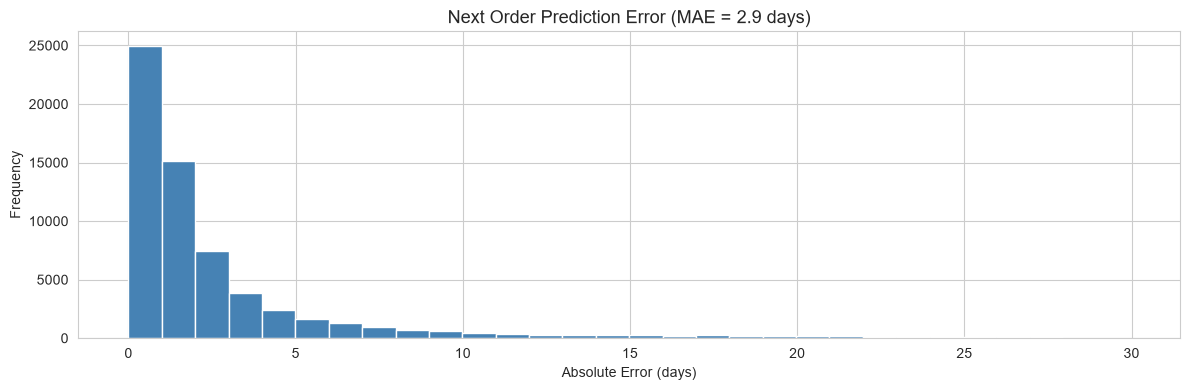

In [9]:
# Train & evaluate
print('Training Linear Regression baseline...')
lr_r  = LinearRegression()
lr_r.fit(X_tr_r, y_tr_r)
lr_p  = np.clip(lr_r.predict(X_vl_r), 0, 60)
print(f'LR  — MAE: {mean_absolute_error(y_vl_r, lr_p):.2f} days | R2: {r2_score(y_vl_r, lr_p):.4f}')

print('\nTraining XGBoost Regressor...')
xgb_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_reg.fit(X_tr_r, y_tr_r, eval_set=[(X_vl_r, y_vl_r)], verbose=50)
xgb_p = np.clip(xgb_reg.predict(X_vl_r), 0, 60)

mae  = mean_absolute_error(y_vl_r, xgb_p)
rmse = np.sqrt(mean_squared_error(y_vl_r, xgb_p))
r2   = r2_score(y_vl_r, xgb_p)
errors = np.abs(xgb_p - y_vl_r)

print(f'\nXGBoost — MAE: {mae:.2f} days | RMSE: {rmse:.2f} | R2: {r2:.4f}')
print(f'Within 1 day  : {(errors<=1).mean()*100:.1f}%')
print(f'Within 2 days : {(errors<=2).mean()*100:.1f}%')
print(f'Within 3 days : {(errors<=3).mean()*100:.1f}%')

# Error distribution plot
plt.figure(figsize=(12,4))
plt.hist(errors[errors<=30], bins=30, color='steelblue', edgecolor='white')
plt.title(f'Next Order Prediction Error (MAE = {mae:.1f} days)', fontsize=13)
plt.xlabel('Absolute Error (days)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

In [10]:
# Retrain on full Jan–Apr data, then predict next order date for all retailers
print('Retraining regression model on full Jan–Apr data...')
train_all = reg_df[reg_df['createdAt'] <= '2026-04-30']
X_all_r = np.nan_to_num(train_all[REG_FEATURES].values, nan=0.0)
y_all_r = train_all[TARGET_R].values

xgb_reg_final = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_reg_final.fit(X_all_r, y_all_r, verbose=50)

# Save regression model
with open(REG_MODEL_PATH, 'wb') as f:
    pickle.dump({'model': xgb_reg_final, 'feature_cols': REG_FEATURES}, f)
print(f'✅ Regression model saved → {REG_MODEL_PATH}')

Retraining regression model on full Jan–Apr data...


✅ Regression model saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_next_order_model.pkl


In [11]:
# Predict next order date for every retailer using their last order as reference
last_orders = orders.sort_values('createdAt').groupby('customerId').last().reset_index()

pred_df = (
    last_orders[['customerId','createdAt','hubName','shopType','retailerType','orderSource']]
    .merge(gap_stats_r, on='customerId', how='left')
    .merge(app_r,       on='customerId', how='left')
    .merge(retailer_profile[['customerId','first_order']], on='customerId', how='left')
)

pred_df['day_of_week']  = pred_df['createdAt'].dt.dayofweek
pred_df['month']        = pred_df['createdAt'].dt.month
pred_df['is_weekend']   = (pred_df['createdAt'].dt.dayofweek >= 5).astype(int)
pred_df['day_of_month'] = pred_df['createdAt'].dt.day

for col in ['hubName','shopType','retailerType']:
    le    = label_encoders[col]
    known = set(le.classes_)
    pred_df[col]        = pred_df[col].apply(lambda x: x if str(x) in known else le.classes_[0])
    pred_df[col+'_enc'] = le.transform(pred_df[col].fillna('Unknown').astype(str))

pred_df = pred_df.fillna({'avg_gap':7,'std_gap':0,'median_gap':7,
                           'min_gap':0,'max_gap':0,'count':1,
                           'app_order_ratio':0.5,'tenure_days':0})

pred_df['tenure_days'] = (pred_df['createdAt'] - pd.to_datetime(pred_df['first_order'])).dt.days
pred_df['tenure_days'] = pred_df['tenure_days'].clip(lower=0).fillna(0)
X_pred = np.nan_to_num(pred_df[REG_FEATURES].values, nan=0.0)
pred_df['predicted_days_until_next'] = np.clip(xgb_reg_final.predict(X_pred), 1, 60).round(1)

REFERENCE_DATE = pd.Timestamp('2026-04-30')  # last day of training data
pred_df['predicted_next_order_date'] = (
    REFERENCE_DATE + pd.to_timedelta(pred_df['predicted_days_until_next'], unit='D')
).dt.date
pred_df['last_order_date'] = pred_df['createdAt'].dt.date

schedule = pred_df[[
    'customerId','hubName','shopType','retailerType',
    'last_order_date','avg_gap','predicted_days_until_next','predicted_next_order_date'
]].rename(columns={'avg_gap':'historical_avg_gap_days'}).sort_values('predicted_next_order_date')

print(f'=== NEXT ORDER SCHEDULE — First 20 ===')
print(schedule.head(20).to_string(index=False))

sch_path = os.path.join(OUTPUTS_DIR, 'next_order_prediction_may2026.csv')
schedule.to_csv(sch_path, index=False)
print(f'\n✅ Next order schedule saved → {sch_path}')

=== NEXT ORDER SCHEDULE — First 20 ===
customerId                       hubName  shopType retailerType last_order_date  historical_avg_gap_days  predicted_days_until_next predicted_next_order_date
  USR-3582           Instant Foods (GZB)    Paan B         HVHF      2026-05-29                 1.783133                        1.9                2026-05-01
 USR-77151   NB Enterprises (West Delhi)    Paan A         HVHF      2026-05-28                 1.678161                        1.4                2026-05-01
 USR-27315      Crossline Events (Noida)    Paan B         HVHF      2026-05-29                 1.505618                        1.5                2026-05-01
   USR-773          Instant Foods(Noida)    Paan B         HVHF      2026-05-29                 1.275862                        1.2                2026-05-01
USR-161474          Instant Foods(Noida)    Paan A         HVHF      2026-05-27                 1.611111                        1.5                2026-05-01
USR-175008   

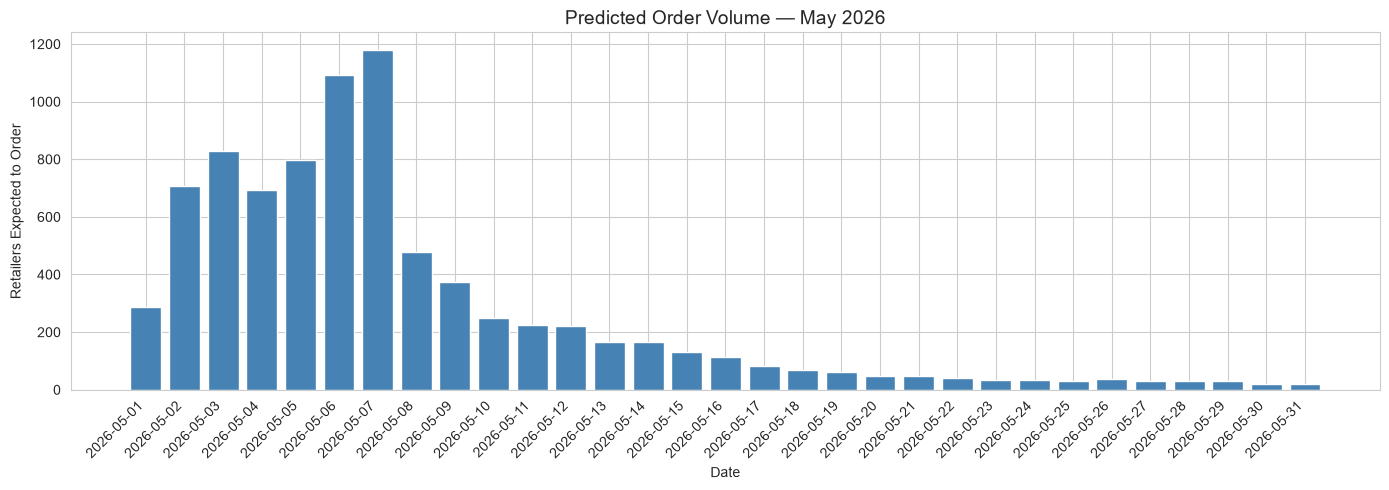


=== NOTEBOOK B COMPLETE ===
Files saved in outputs/:
  .ipynb_checkpoints
  call_priority_2026-05-15.csv
  call_priority_2026-05-31.csv
  call_priority_2026-06-01.csv
  june_2026_call_schedule.csv
  june_call_plan.csv
  may_2026_call_schedule.csv
  next_order_prediction.csv
  next_order_prediction_june2026.csv
  next_order_prediction_may2026.csv


In [12]:
# Plot predicted order volume across May
daily_pred = (
    schedule
    .groupby('predicted_next_order_date').size()
    .reset_index()
)
daily_pred.columns = ['Date','Predicted Orders']
daily_pred = daily_pred[
    (daily_pred['Date'] >= pd.Timestamp('2026-05-01').date()) &
    (daily_pred['Date'] <= pd.Timestamp('2026-05-31').date())
]

plt.figure(figsize=(14, 5))
plt.bar(daily_pred['Date'].astype(str), daily_pred['Predicted Orders'],
        color='steelblue', edgecolor='white')
plt.title('Predicted Order Volume — May 2026', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Retailers Expected to Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('\n=== NOTEBOOK B COMPLETE ===')
print('Files saved in outputs/:')
for f in os.listdir(OUTPUTS_DIR):
    print(f'  {f}')